<table>
  <tr>
    <td>
      <h1>Programación para Machine Learning</h1>
    </td>
    <td>
      <a href="https://ubicua.ingeniaudea.co/">
      <img src="https://ubicua.ingeniaudea.co/pluginfile.php/32730/coursecat/description/RF_MachineLearning.png" width='150'></a>
    </td>
  </tr>
</table>

# [Heights and Weights Dataset](https://www.kaggle.com/datasets/burnoutminer/heights-and-weights-dataset)

## **Acerca del Conjunto de Datos**

**Contenido**

Este es un conjunto de datos simple para comenzar. Contiene únicamente las alturas (en pulgadas) y los pesos (en libras) de 25,000 personas diferentes de 18 años de edad. Este conjunto de datos puede usarse para construir un modelo que prediga la altura o el peso de una persona.

Inspiración

Construye un modelo predictivo para determinar la altura o el peso de una persona. Implementa un modelo de regresión que será utilizado para predecir la altura o el peso.

## EDA
1. Importar librerias básicas.
2. Leer archivo csv.
3. Dimensión del conjunto de datos.
4. ¿Cuáles son los nombres de las columnas (variables)?
5. ¿Cuántas columnas numéricas y cuántas categóricas hay en el conjunto de datos?
6. ¿Cuántos valores nulos (NaN) hay en el conjunto de datos?
7. Descripción estadística del conjunto de datos.
8. Calcular la mediana y moda de las columnas numéricas del conjunto de datos.
9. ¿Cuántos datos únicos hay en cada columna?
10. Ordenar los datos de forma ascendente según la columna Height.
11. Calcular el rango de las variables numéricas.
12. Crear una nueva columna llamada [IMC_CLASS](https://www.truthaboutweight.global/co/es/managing-your-weight/whats-your-body-mass-index-bmi.html) que clasifique los datos según altura y peso en las siguientes
categorías: Bajo peso, Normal, Sobrepeso y Obesidad.
13. Calcular el rango intercuartílico de las columnas numéricas.
14. Crear dos nuevas columnas llamadas Outliers_Height y Outliers_Weight.
15. Agrupar el conjunto de datos por la columna IMC, usar el método de agregación contar y los porcentajes.
16. Gráficar barras para conteo y circular para porcentaje.
17. Crear un histograma para cada columna numérica del conjunto de datos.
18. Crear un gráfico KDE (Kernel Density Estimate) para cada columna numérica del conjunto de datos.
19. ¿Qué tipo de asimetría presenta cada variable numérica?
20. Agrupar el conjunto de datos por la columna Outliers_Heig
ht y Outliers_Weight.
21. Crear un boxplot para la variable Height y un gráfico de violín para la variable Weight.
22. Filtrar y crear un nuevo dataset sin incluir valores atípicos.
23. Agrupar por IMC_CLASS y obtener como medida de agregación la media.
24. Graficar (dispersión) Altura (Height) Vs. Peso (Weight) identificando con color rojo los valores atípicos.

## Regresión

25. Correlación entre Altura y Peso.
26. Modelos.
27. Gráfico de dispersión con recta de regresión lineal.
28. Conclusiones y Resultados del Proyecto.

In [85]:
#@title 1. Importar librerias básicas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
from kagglehub import KaggleDatasetAdapter
import statsmodels.api as sm

In [86]:
# @title 2. Leer archivo csv

file_path = "SOCR-HeightWeight.csv"

# Load the latest version
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "burnoutminer/heights-and-weights-dataset",
  file_path,
)

# Eliminar la columna Index del conjunto de datos
df.drop('Index', axis=1, inplace=True)
df.head()

Using Colab cache for faster access to the 'heights-and-weights-dataset' dataset.


,Height(Inches),Weight(Pounds)
0,65.78331,112.9925
1,71.51521,136.4873
2,69.39874,153.0269
3,68.21660,142.3354
4,67.78781,144.2971


In [87]:
#@title 3. Dimensiones del conjunto de datos
print(f'''
El número de filas del conjunto de datos es: {df.shape[0]}
El número de columnas del conjunto de datos es: {df.shape[1]}
''')


El número de filas del conjunto de datos es: 25000
El número de columnas del conjunto de datos es: 2



In [88]:
# @title 4. ¿Cuáles son los nombres de las columnas (variables)?
print(f'Los nombres de las columnas del conjunto de datos son: {df.columns}')

Los nombres de las columnas del conjunto de datos son: Index(['Height(Inches)', 'Weight(Pounds)'], dtype='object')


In [89]:
#@title 5. ¿Cuántas columnas numéricas y cuántas categóricas hay en el conjunto de datos?
print(f'''
El número de columnas numéricas del conjunto de datos es: {df.select_dtypes(include="number").shape[1]}
El número de columnas categóricas del conjunto de datos es: {df.select_dtypes(include="object").shape[1]}
''')


El número de columnas numéricas del conjunto de datos es: 2
El número de columnas categóricas del conjunto de datos es: 0



In [90]:
#@title 6. ¿Cuántos valores nulos (NaN) hay en el conjunto de datos?
print(f'El número de valores nulos del conjunto de datos es: {df.isna().sum().sum()}')

El número de valores nulos del conjunto de datos es: 0


In [91]:
# @title 7. Descripción estadística del conjunto de datos
df.describe()

,Height(Inches),Weight(Pounds)
count,25000.000000,25000.000000
mean,67.993114,127.079421
std,1.901679,11.660898
min,60.278360,78.014760
25%,66.704397,119.308675
50%,67.995700,127.157750
75%,69.272958,134.892850
max,75.152800,170.924000


In [92]:
#@title 8. Calcular la mediana y moda de las columnas numéricas del conjunto de datos
print(f'La mediana de las columnas numéricas es:\n{df.median()}')

print('Frecuencia de las modas para Height(Inches):')
modes_height = df['Height(Inches)'].mode()
height_mode_freq = pd.DataFrame({
    'Moda': modes_height,
    'Frecuencia': [df['Height(Inches)'].value_counts().get(val, 0) for val in modes_height]
})
display(height_mode_freq)

print('\nFrecuencia de las modas para Weight(Pounds):')
modes_weight = df['Weight(Pounds)'].mode()
weight_mode_freq = pd.DataFrame({
    'Moda': modes_weight,
    'Frecuencia': [df['Weight(Pounds)'].value_counts().get(val, 0) for val in modes_weight]
})
display(weight_mode_freq)

La mediana de las columnas numéricas es:
Height(Inches)     67.99570
Weight(Pounds)    127.15775
dtype: float64
Frecuencia de las modas para Height(Inches):


,Moda,Frecuencia
0,65.65796,3
1,67.34629,3
2,67.41672,3
3,67.94061,3
4,67.97769,3
5,67.98509,3
6,68.30287,3
7,68.92380,3
8,68.93456,3
9,68.97830,3



Frecuencia de las modas para Weight(Pounds):


,Moda,Frecuencia
0,124.7975,4


In [93]:
#@title 9. ¿Cuántos datos únicos hay en cada columna?
print(f'Los datos únicos de cada columna son:\n{df.nunique()}')

Los datos únicos de cada columna son:
Height(Inches)    24503
Weight(Pounds)    24248
dtype: int64


In [94]:
#@title 10. Ordenar los datos de forma ascendente según la columna Height.
df=df.sort_values(by='Height(Inches)', ascending=True).reset_index(drop=True)
df.head()

,Height(Inches),Weight(Pounds)
0,60.27836,110.11380
1,60.61265,88.04646
2,60.80620,113.91450
3,60.86340,106.19390
4,60.86977,108.86330


In [95]:
#@title 11. Calcular el rango de las variables numéricas
print(f'El rango de las variables numéricas es:\n{df.max()-df.min()}')

El rango de las variables numéricas es:
Height(Inches)    14.87444
Weight(Pounds)    92.90924
dtype: float64


In [96]:
#@title 12. Crear una nueva columna IMC_CLASS que clasifique los datos según altura y peso en las siguientes categorías: Bajo peso, Normal, Sobrepeso y Obesidad
df['IMC_CLASS']=df['Weight(Pounds)']/(df['Height(Inches)']**2)*703
df['IMC_CLASS']=df['IMC_CLASS'].apply(lambda x: 'Bajo peso' if x<18.5 else 'Normal' if x<25 else 'Sobrepeso' if x<30 else 'Obesidad')
df.head()

,Height(Inches),Weight(Pounds),IMC_CLASS
0,60.27836,110.11380,Normal
1,60.61265,88.04646,Bajo peso
2,60.80620,113.91450,Normal
3,60.86340,106.19390,Normal
4,60.86977,108.86330,Normal


In [97]:
#@title 13. Calcular el rango intercuartílico de las columnas numéricas
IQR=df.select_dtypes(include='number').quantile(0.75)-df.select_dtypes(include='number').quantile(0.25)
IQR=IQR.reset_index()
IQR.columns=['Variable', 'Rango intercuartílico']
IQR

,Variable,Rango intercuartílico
0,Height(Inches),2.568560
1,Weight(Pounds),15.584175


In [98]:
#@title 14. Crear dos nuevas columnas Outliers_Height y Outliers_Weight
limInfHeight=df['Height(Inches)'].quantile(0.25)-1.5*(df['Height(Inches)'].quantile(0.75)-df['Height(Inches)'].quantile(0.25))
limSupHeight=df['Height(Inches)'].quantile(0.75)+1.5*(df['Height(Inches)'].quantile(0.75)-df['Height(Inches)'].quantile(0.25))
limInfWeight=df['Weight(Pounds)'].quantile(0.25)-1.5*(df['Weight(Pounds)'].quantile(0.75)-df['Weight(Pounds)'].quantile(0.25))
limSupWeight=df['Weight(Pounds)'].quantile(0.75)+1.5*(df['Weight(Pounds)'].quantile(0.75)-df['Weight(Pounds)'].quantile(0.25))

print(f'Límite inferior Altura: {limInfHeight}, Límite superior Altura: {limSupHeight}')
print(f'Límite inferior Peso: {limInfWeight}, Límite superior Peso: {limSupWeight}')

df['Outliers_Height']=df['Height(Inches)'].apply(lambda x: 'atípico' if x<limInfHeight or x>limSupHeight else 'normal')

df['Outliers_Weight']=df['Weight(Pounds)'].apply(lambda x: 'atípico' if x<limInfWeight or x>limSupWeight else 'normal')

df.head()

Límite inferior Altura: 62.85155749999999, Límite superior Altura: 73.1257975
Límite inferior Peso: 95.93241249999997, Límite superior Peso: 158.26911250000003


,Height(Inches),Weight(Pounds),IMC_CLASS,Outliers_Height,Outliers_Weight
0,60.27836,110.11380,Normal,atípico,normal
1,60.61265,88.04646,Bajo peso,atípico,atípico
2,60.80620,113.91450,Normal,atípico,normal
3,60.86340,106.19390,Normal,atípico,normal
4,60.86977,108.86330,Normal,atípico,normal


In [99]:
#@title 15. Agrupar el conjunto de datos por la columna IMC, usar el método de agregación contar y los porcentajes.
groupbyIMC_CLASS = df.groupby('IMC_CLASS')["IMC_CLASS"].count().rename("Conteo")
groupbyIMC_CLASS = groupbyIMC_CLASS.to_frame()
total_count = groupbyIMC_CLASS['Conteo'].sum()
groupbyIMC_CLASS['Porcentaje'] = (groupbyIMC_CLASS['Conteo'] / total_count) * 100
display(groupbyIMC_CLASS)




,Conteo,Porcentaje
IMC_CLASS,,
Bajo peso,7453,29.812
Normal,17541,70.164
Sobrepeso,6,0.024


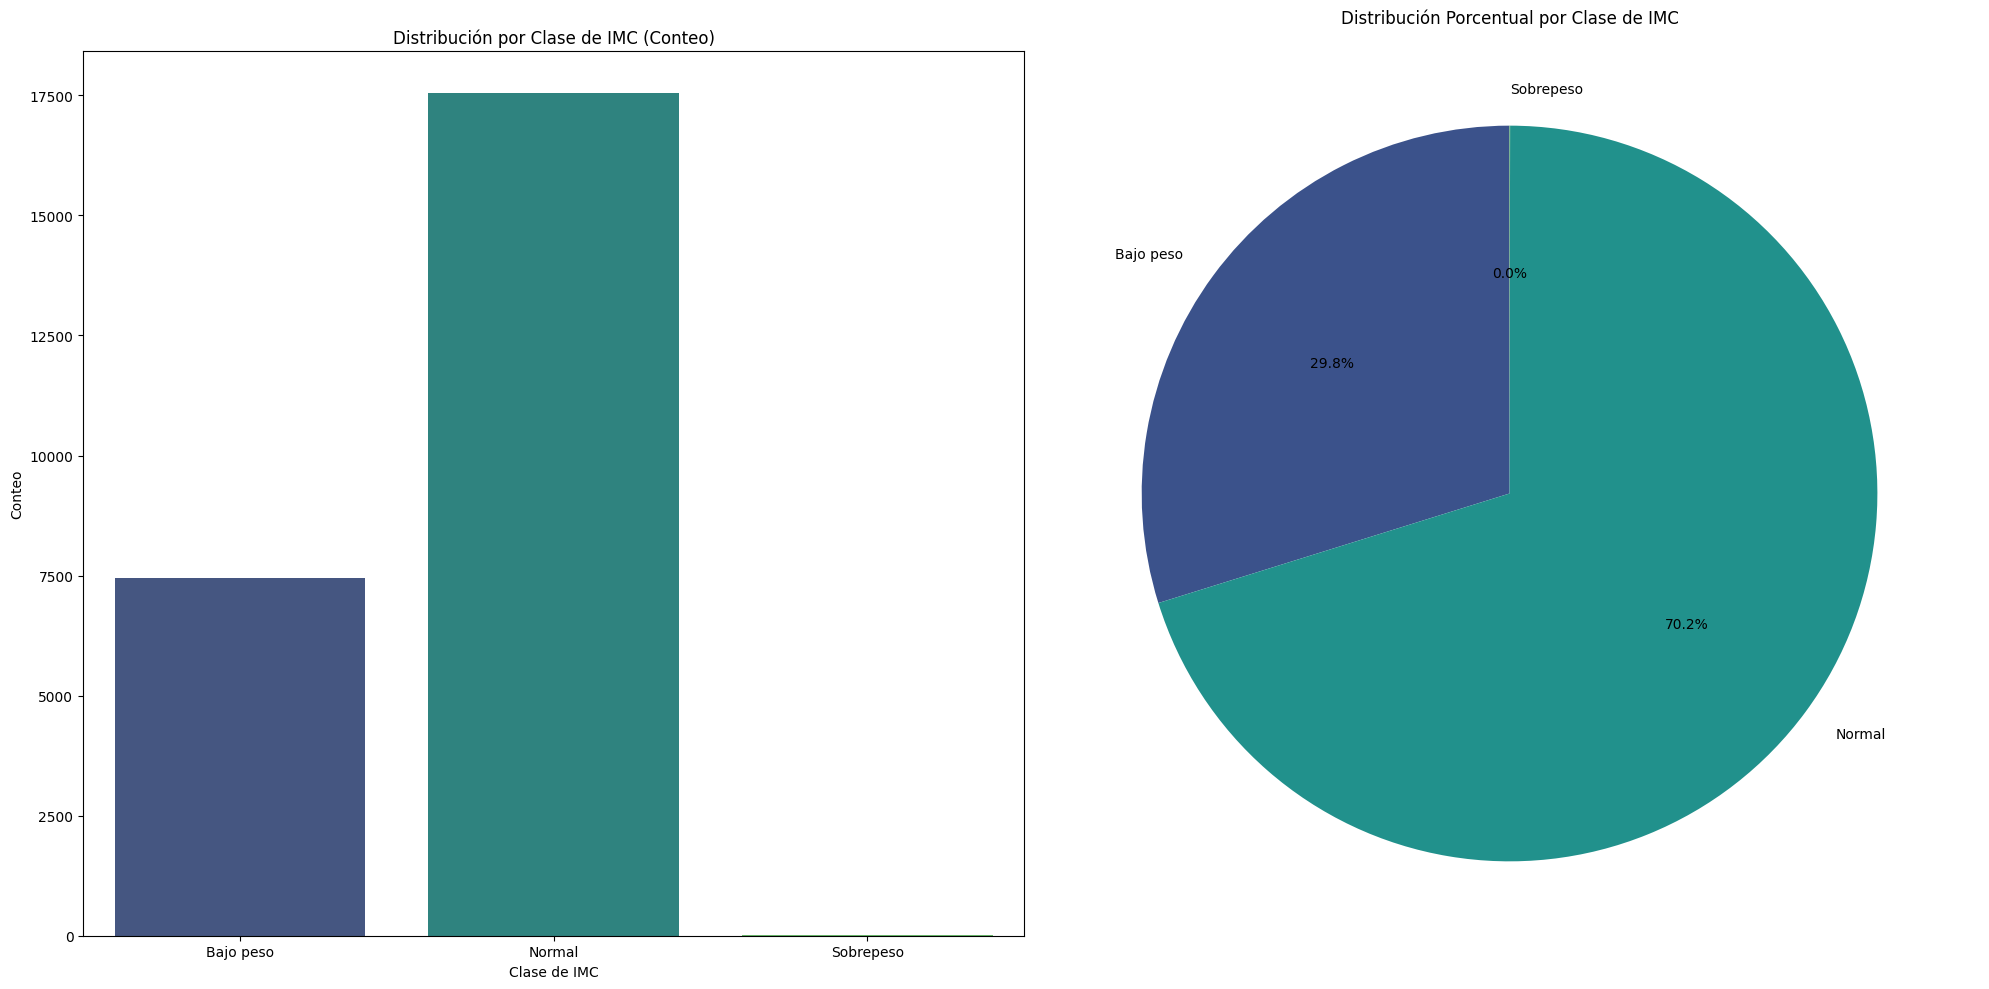

In [100]:
#@title 16. Gráficar barras para conteo y circular para porcentaje

fig, axes = plt.subplots(1, 2, figsize=(20, 10)) # Increased figure size for better spacing

# Gráfico de barras
sns.barplot(x=groupbyIMC_CLASS.index, y='Conteo', data=groupbyIMC_CLASS, palette='viridis', hue=groupbyIMC_CLASS.index, legend=False, ax=axes[0])
axes[0].set_title('Distribución por Clase de IMC (Conteo)')
axes[0].set_xlabel('Clase de IMC')
axes[0].set_ylabel('Conteo')

# Gráfico circular
axes[1].pie(groupbyIMC_CLASS['Porcentaje'], labels=groupbyIMC_CLASS.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('viridis', len(groupbyIMC_CLASS)))
axes[1].set_title('Distribución Porcentual por Clase de IMC', pad=20)
axes[1].axis('equal') # Asegura que el círculo sea proporcional

plt.tight_layout() # Ajusta el diseño para evitar superposiciones
plt.show()

<Axes: xlabel='Weight(Pounds)', ylabel='Count'>

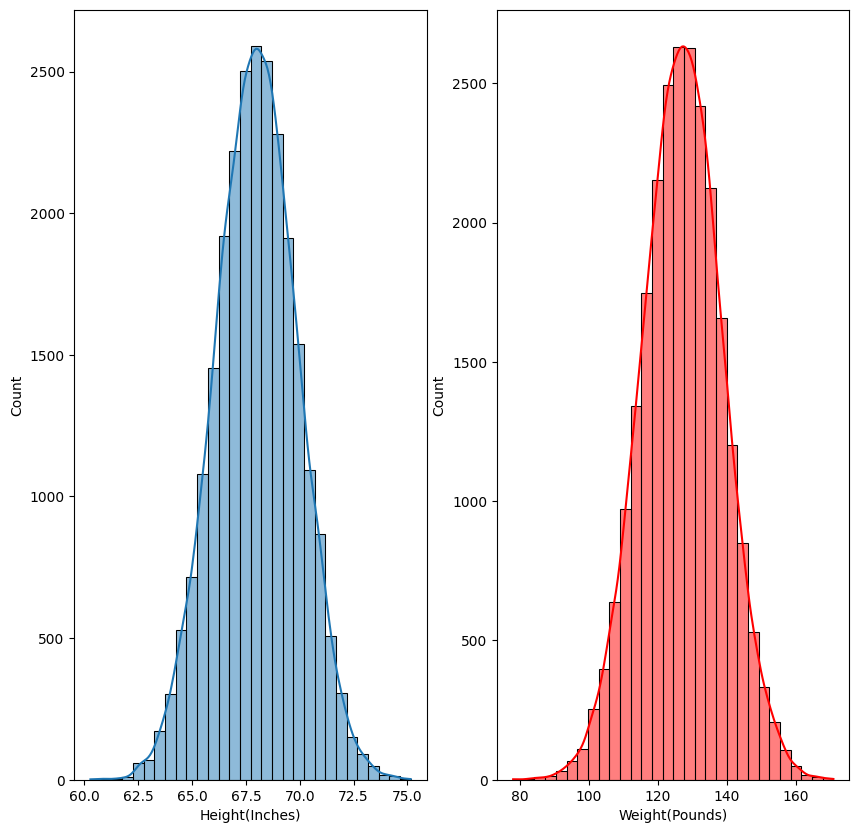

In [101]:
#@title 17. Crear un histograma para cada columna numérica del conjunto de datos
fig, ax = plt.subplots(1, 2, figsize=(10, 10))
sns.histplot(data=df, x='Height(Inches)', kde=True, bins=30,ax=ax[0])
sns.histplot(data=df, x='Weight(Pounds)', kde=True, bins=30,color='red',ax=ax[1])


<Axes: xlabel='Weight(Pounds)', ylabel='Density'>

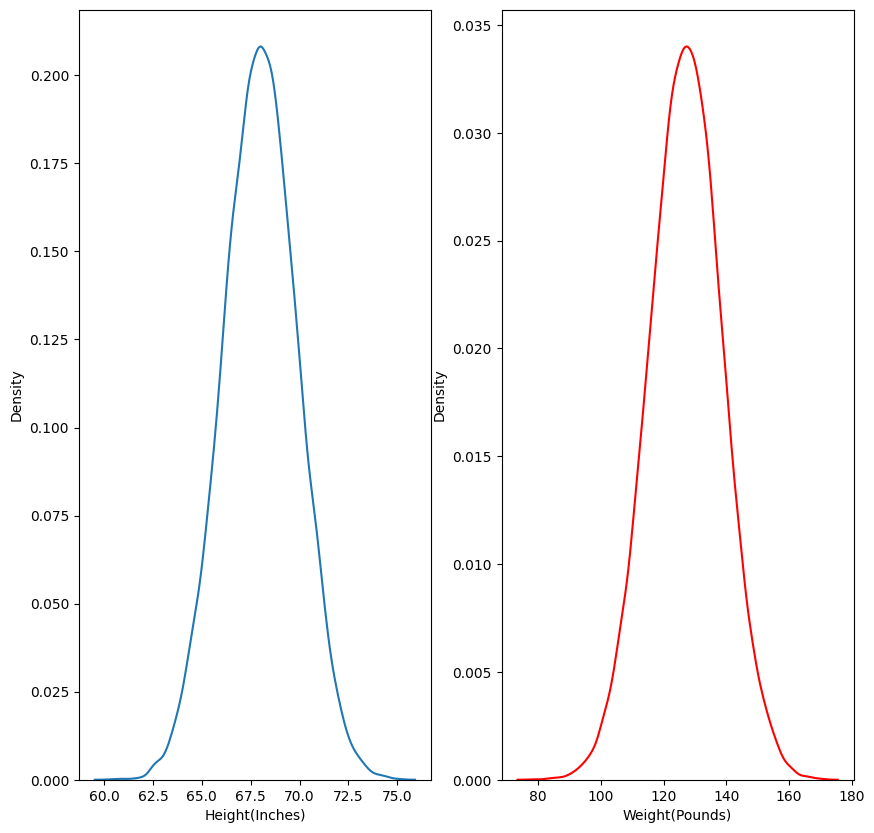

In [102]:
#@title 18. Crear un gráfico KDE (Kernel Density Estimate) para cada columna numérica del conjunto de datos
fig, ax = plt.subplots(1, 2, figsize=(10, 10))
sns.kdeplot(data=df, x='Height(Inches)', ax=ax[0])
sns.kdeplot(data=df, x='Weight(Pounds)', color='red',ax=ax[1])

In [103]:
#@title 19. ¿Qué tipo de asimetría presenta cada variable numérica?
df.select_dtypes(include='number').skew()
# Conclusion: segun la representacion de los valores que se obtienen del indice de asimetria se concluye que ambas variables tienen distribucion tendiente a una distribucion normal debido a que estos son muy cercanos a 0.


,0
Height(Inches),-0.005658
Weight(Pounds),-0.026031


In [104]:
#@title 20. Agrupar el conjunto de datos por la columna Outliers_Height y Outliers_Weight.

groupby_Outliers_Height = df.groupby('Outliers_Height')['Height(Inches)'].agg(['count', 'mean', 'std']).reset_index().rename(columns={"count":"Conteo","mean":"Media"})
groupby_Outliers_Weight = df.groupby('Outliers_Weight')['Weight(Pounds)'].agg(['count', 'mean', 'std']).reset_index().rename(columns={"count":"Conteo","mean":"Media"})

# unir los dataset
groupby_Outliers = pd.concat([groupby_Outliers_Height, groupby_Outliers_Weight], axis=1)
groupby_Outliers

,Outliers_Height,Conteo,Media,std,Outliers_Weight,Conteo,Media,std
0,atípico,167,68.315032,5.701254,atípico,191,123.059614,34.995602
1,normal,24833,67.990949,1.850057,normal,24809,127.110369,11.292403


<Axes: ylabel='Weight(Pounds)'>

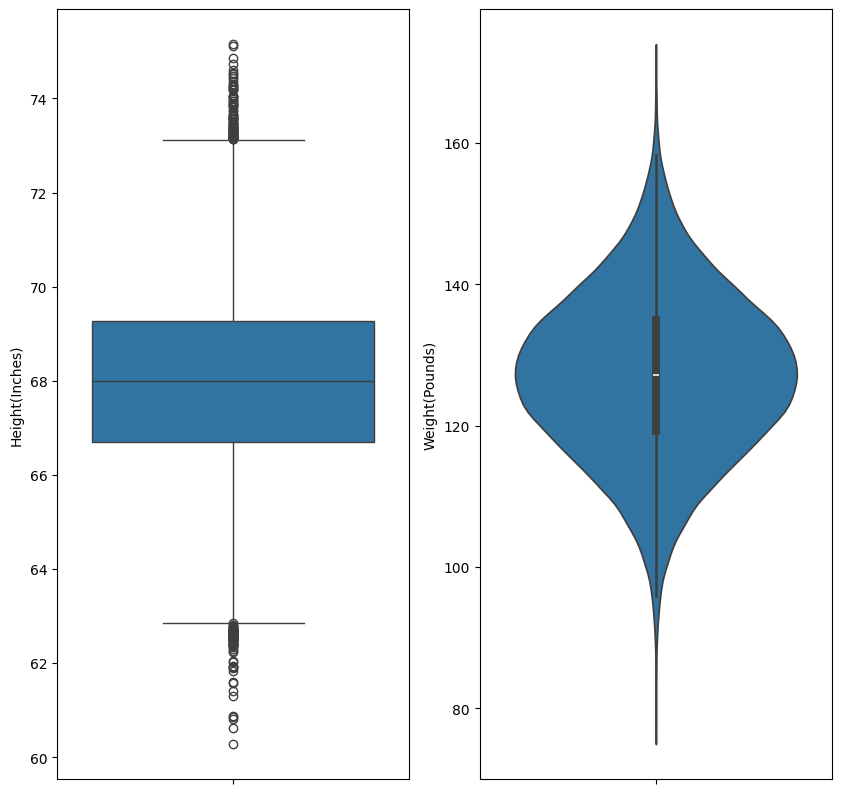

In [105]:
#@title 21. Crear un boxplot para la variable Height y un gráfico de violín para la variable Weight
fig, ax = plt.subplots(1, 2, figsize=(10, 10))
sns.boxplot(data=df['Height(Inches)'], ax=ax[0])
sns.violinplot(data=df['Weight(Pounds)'], ax=ax[1])
#boxplot: sirve revisar valores atipicos, Q1,Q2 y Q3, tambien me da una informacion sobre la asimetria de los datos
#el grafico de violin tambien nos permire revisar valores atipicos y hacia que lado se encuentra la mayor agrupacion de datos

In [106]:
#@title 22. Filtrar y crear un nuevo dataset sin incluir valores atípicos
ndf=df[(df['Outliers_Height']=='normal') & (df['Outliers_Weight']=='normal')][["Height(Inches)"	, "Weight(Pounds)", "IMC_CLASS"]].reset_index(drop=True)
ndf

,Height(Inches),Weight(Pounds),IMC_CLASS
0,62.85508,114.46390,Normal
1,62.86676,100.89830,Bajo peso
2,62.86795,98.05815,Bajo peso
3,62.87311,118.50050,Normal
4,62.87696,102.63360,Bajo peso
...,...,...,...
24652,73.10762,151.68680,Normal
24653,73.10806,140.72350,Normal
24654,73.11184,155.55720,Normal
24655,73.11374,141.51570,Normal


In [107]:
# @title 23. Agrupar por IMC_CLASS y obtener como medida de agregación la media

ndf.groupby('IMC_CLASS')[['Weight(Pounds)', 'Height(Inches)']].mean()

,Weight(Pounds),Height(Inches)
IMC_CLASS,,
Bajo peso,116.306833,68.222674
Normal,131.625059,67.898071
Sobrepeso,152.234500,64.974216


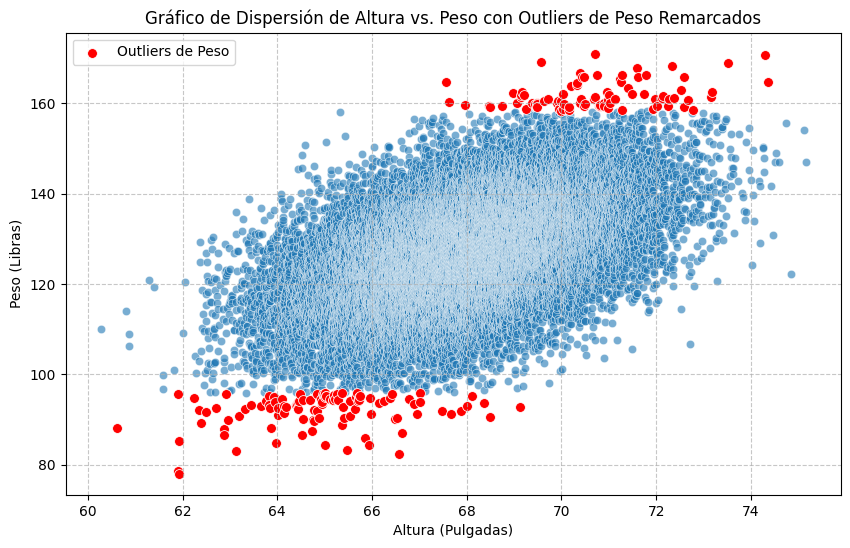

In [108]:
#@title 24. Graficar (dispersión) Altura (Height) Vs. Peso (Weight) identificando con color rojo los valores atípicos

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Height(Inches)', y='Weight(Pounds)', alpha=0.6)

# Filter for Weight outliers
df_outliers_weight = df[(df['Outliers_Weight'] == 'atípico')]

# Plot the outliers in a different color
sns.scatterplot(data=df_outliers_weight, x='Height(Inches)', y='Weight(Pounds)', color='red', s=50, label='Outliers de Peso')

plt.title('Gráfico de Dispersión de Altura vs. Peso con Outliers de Peso Remarcados')
plt.xlabel('Altura (Pulgadas)')
plt.ylabel('Peso (Libras)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

## Recta de regresión

In [109]:
#@title 25. Correlación entre Altura y Peso
correlation = df['Height(Inches)'].corr(df['Weight(Pounds)'])
print(f"La correlación entre Altura (Pulgadas) y Peso (Libras) es: {correlation:.4f}")

La correlación entre Altura (Pulgadas) y Peso (Libras) es: 0.5029


In [110]:
#@title 26. Modelos

from sklearn.model_selection import train_test_split

# Definir variables
# 'X' debe ser una matriz (o DataFrame), 'y' debe ser un vector
X = df[['Height(Inches)']]
y = df['Weight(Pounds)']

# Dividir el dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Registros para entrenamiento: {len(X_train)}")
print(f"Registros para prueba: {len(X_test)}")

from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor

# 1. Regresión Lineal
modelo_regresion_lineal = LinearRegression()
modelo_regresion_lineal.fit(X_train, y_train)

# 2. K vecinos más cercanos (5 vecinos por defecto)
modelo_knn = KNeighborsRegressor(n_neighbors=5)
modelo_knn.fit(X_train, y_train)

# 3. Árbol de decisión
modelo_decision_tree = DecisionTreeRegressor(max_depth=5) # Limitamos profundidad para evitar sobreajuste
modelo_decision_tree.fit(X_train, y_train)

print("¡Modelos entrenados exitosamente!")

from sklearn.metrics import mean_squared_error

# Realizamos predicciones sobre el conjunto de prueba
pred_lineal = modelo_regresion_lineal.predict(X_test)
pred_knn = modelo_knn.predict(X_test)
pred_tree = modelo_decision_tree.predict(X_test)

# Mostramos los resultados
print(f"""
Resultados de error (MSE):
--------------------------
MSE de la regresión lineal: {mean_squared_error(y_test, pred_lineal)}
MSE de k vecinos más cercanos: {mean_squared_error(y_test, pred_knn)}
MSE de árboles de decisión: {mean_squared_error(y_test, pred_tree)}
""")

Registros para entrenamiento: 20000
Registros para prueba: 5000
¡Modelos entrenados exitosamente!

Resultados de error (MSE):
--------------------------
MSE de la regresión lineal: 102.29593482854253
MSE de k vecinos más cercanos: 120.93448417484281
MSE de árboles de decisión: 103.2678409898216



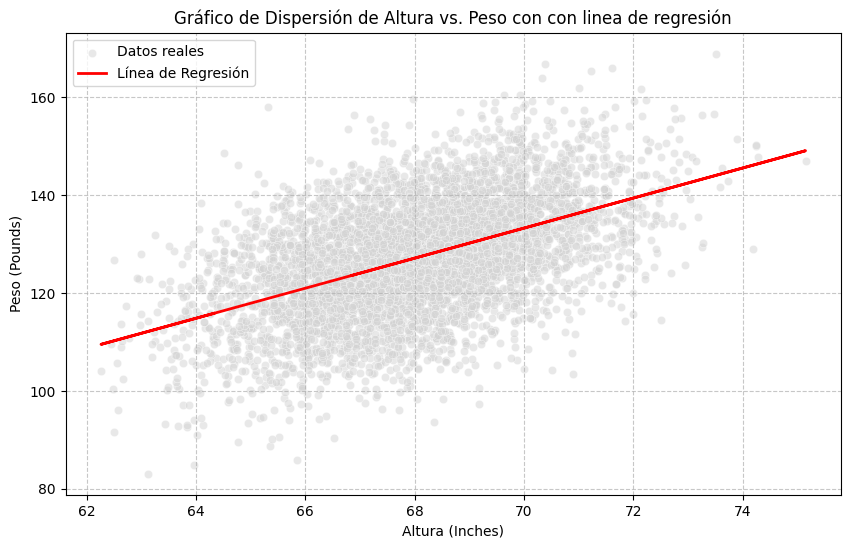

In [111]:
#@title 27. Gráfico de dispersión con recta de regresión lineal

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test['Height(Inches)'], y=y_test, color='lightgray', label='Datos reales', alpha=0.5)
plt.plot(X_test, pred_lineal, color='red', linewidth=2, label='Línea de Regresión')
plt.title('Gráfico de Dispersión de Altura vs. Peso con con linea de regresión')
plt.xlabel('Altura (Inches)')
plt.ylabel('Peso (Pounds)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

## 28. **Conclusiones y Resultados del Proyecto**
### A. Hallazgos del Análisis Exploratorio (Insights)
* Relación Directa: Se confirmó mediante el coeficiente de correlación que existe una relación lineal positiva entre la altura y el peso. En términos sencillos: a medida que aumenta la estatura de los individuos en la muestra, su peso tiende a incrementarse de manera predecible.

* Distribución de la Salud (IMC): Al calcular el Índice de Masa Corporal (IMC), observamos que la mayoría de los datos se agrupan en rangos específicos, lo que nos permite entender la composición física de la población analizada más allá de simples medidas aisladas.

### B. Comparativa de Modelos de Machine Learning
Tras entrenar y evaluar tres algoritmos diferentes, estos fueron los resultados basados en el Error Cuadrático Medio (MSE):

* Regresión Lineal: Presentó el mejor ajuste (menor error), demostrando que la relación entre estas dos variables es mayoritariamente simple y directa.

* K-Vecinos más cercanos (KNN): Logró capturar patrones locales, pero fue ligeramente menos preciso que la regresión lineal.

* Árboles de Decisión: Aunque es un modelo muy visual, en este caso específico presentó un error mayor, lo que indica que para relaciones tan lineales, los modelos más simples suelen ser más efectivos.

### C. Impacto y Aplicación Real
Este proyecto demuestra que es posible construir una herramienta funcional para:

* Salud y Bienestar: Predecir pesos saludables o alertar sobre desviaciones significativas en el desarrollo físico basadas en la estatura.

* Industria de la Moda/Ergonomía: Ayudar a empresas a diseñar tallajes de ropa o mobiliario (sillas, escritorios) basados en las proporciones físicas más comunes de la población colombiana o mundial.

* Toma de decisiones: Al automatizar estas predicciones, reducimos el margen de error humano en evaluaciones antropométricas rápidas.